In [1]:
import shap
print("SHAP WORKING ✔")

c:\CodeAlpha_DiseasePredictionFromMedicalData\src\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SHAP WORKING ✔


In [12]:
import pandas as pd

df = pd.read_csv("../data/processed/heart_cleaned.csv")

print("Data loaded ✔", df.shape)

Data loaded ✔ (297, 14)


In [13]:
from sklearn.model_selection import train_test_split

X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Data ready ✔", X_test.shape)

Data ready ✔ (60, 13)


In [14]:
import joblib

model = joblib.load("../models/heart_model.pkl")

print("Model loaded ✔")

Model loaded ✔


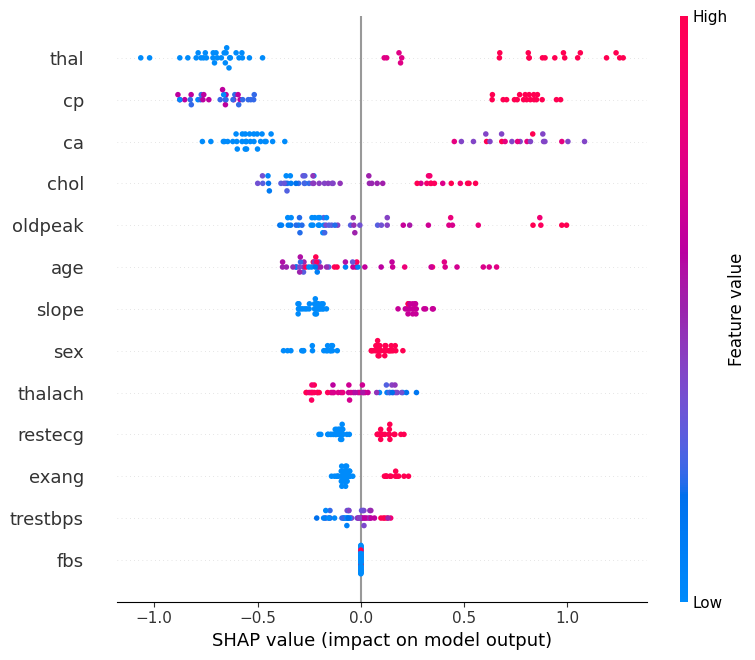

In [15]:
import shap
import matplotlib.pyplot as plt

explainer = shap.TreeExplainer(model)

# small sample for speed
X_sample = X_test[:50]

shap_values = explainer.shap_values(X_sample)

shap.summary_plot(shap_values, X_sample)

plt.show()

In [16]:
plt.savefig("../outputs/shap_summary.png")

<Figure size 640x480 with 0 Axes>

## SHAP Explainability Insights

SHAP analysis was used to interpret the predictions of the XGBoost model.

Key observations:

- `thal`, `ca`, and `oldpeak` are the most influential features
- Higher values of `oldpeak` significantly increase the probability of heart disease
- Chest pain type (`cp`) shows strong contribution toward classification
- Lower maximum heart rate (`thalach`) is associated with higher disease risk

This confirms that the model is learning medically relevant patterns rather than random correlations.

## Explainability

SHAP (SHapley Additive exPlanations) was used to interpret model predictions.

The analysis shows that features such as `thal`, `ca`, and `oldpeak` have the highest impact on heart disease prediction.

This ensures the model is not only accurate but also interpretable.